# Comparison of RedDB reaction energies and experimental redox potentials

This notebook demonstrates the integration of external computational data from RedDB
with experimentally measured redox potentials retrieved through the OFBO virtual
knowledge graph.

RedDB provides calculated reaction energies for oxidized and reduced molecular forms.
The OFBO query retrieves experimentally measured redox potentials, their associated
pH values, and molecular InChIKeys. InChIKeys are then used in Python to match RedDB
reactants to experimentally characterized molecules.

Experimental potentials are normalized to pH 0 using the empirical pH dependence
obtained in the preceding Nernst analysis, with a slope of −0.050 V per pH unit.
The matched data are subsequently evaluated using a linear regression.

This is a proof-of-concept cross-resource comparison. The number of matched molecules
is expected to be small because RedDB and the experimentally curated OFBO datasets
contain different molecular scaffold distributions.

In [ ]:
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display


ONTOP_ENDPOINT = "http://localhost:8080/sparql"
TIMEOUT_SECONDS = 120

## 1. SPARQL query and retrieval of experimental redox potentials

The query retrieves experimentally generated redox potentials reported versus SHE,
together with the molecular InChIKey, the pH of the measurement system, and the
primary source.

The InChIKey enables the subsequent matching of experimental OFBO records to the
oxidized reactant structures listed in the external RedDB dataset.

In [2]:
query_file = Path("queries/query_reddb_experimental_potentials.rq")
query = query_file.read_text(encoding="utf-8")

display(Markdown(f"```sparql\n{query}\n```"))

```sparql
PREFIX ofbo:   <https://w3id.org/ofbo#>
PREFIX schema: <http://schema.org/>
PREFIX sio:    <http://semanticscience.org/resource/>
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX qudt:   <http://qudt.org/schema/qudt/>

SELECT DISTINCT
    ?inchiKey
    ?experimentalPotential
    ?reference
    ?pH
    ?source
WHERE {
    ?molecule a ofbo:OFBO_0000012 ;
              ofbo:OFBO_0009101 "c1ccc2nc3ccccc3nc2c1" ;
              schema:inChIKey ?inchiKey ;
              ofbo:OFBO_0009206 ?reaction .

    ?potential a ofbo:OFBO_0001104 ;
               sio:SIO_000011 ?reaction ;
               qudt:numericValue ?experimentalPotential ;
               ofbo:OFBO_0009202 ?reference ;
               prov:wasGeneratedBy ?experiment ;
               prov:hadPrimarySource ?source .

    # Keep experimentally generated, rather than calculated, potentials.
    ?experiment a ofbo:OFBO_0008500 .

    # pH is absent for some experimental datasets, so retain it when available.
    OPTIONAL {
        ?experiment prov:used ?system .
        ?system sio:SIO_000223 ?pHProperty .

        ?pHProperty a ofbo:OFBO_0001016 ;
                    qudt:numericValue ?pH .
    }
}
ORDER BY ?inchiKey ?source ?pH
```

In [3]:
response = requests.post(
    ONTOP_ENDPOINT,
    data={"query": query},
    headers={"Accept": "text/csv"},
    timeout=TIMEOUT_SECONDS,
)

response.raise_for_status()

experimental_raw = pd.read_csv(StringIO(response.text)).drop_duplicates()

experimental_raw["experimentalPotential"] = pd.to_numeric(
    experimental_raw["experimentalPotential"],
    errors="coerce",
)

experimental_raw["pH"] = pd.to_numeric(
    experimental_raw["pH"],
    errors="coerce",
)

experimental_raw = experimental_raw.dropna(
    subset=["inchiKey", "experimentalPotential", "pH"]
).copy()

print(f"Retrieved {len(experimental_raw)} experimental redox-potential records.")
print(f"Retrieved {experimental_raw['inchiKey'].nunique()} unique molecules.")

experimental_raw.head()

Retrieved 11 experimental redox-potential records.
Retrieved 10 unique molecules.


,inchiKey,experimentalPotential,reference,pH,source
0,DXEXHZLEQUEOGG-UHFFFAOYSA-N,-0.86,SHE,14,https://doi.org/10.1038/s41560-018-0167-3
1,FSNHVRFXRAUXFJ-UHFFFAOYSA-N,-0.74,NHE,14,https://doi.org/10.1039/D1TA03655F
2,GDKLWFNUGWTYRJ-UHFFFAOYSA-N,-0.90,NHE,14,https://doi.org/10.1039/D1TA03655F
3,JOXNFMAXWAPITK-UHFFFAOYSA-N,-0.84,NHE,14,https://doi.org/10.1039/D1TA03655F
4,NSEDHNPVOKTARI-UHFFFAOYSA-N,-0.82,SHE,14,https://doi.org/10.1038/s41560-018-0167-3


## 2. Match RedDB reaction energies with normalized experimental potentials

The RedDB file contains oxidized reactant identifiers, reduced product identifiers,
molecular structures, InChIKeys, electronic energies, and calculated reaction energies.

Experimental records are matched to RedDB oxidized reactants using the InChIKey.
Experimental potentials are normalized to pH 0 using the empirical ensemble slope of
−0.050 V per pH unit obtained from the pH-dependence analysis.

A least-squares linear regression is fitted between the RedDB reaction energy and the
normalized experimental redox potential. The coefficient of determination is reported
as a descriptive measure of the association within the limited matched dataset.

RedDB reactions: 15882
Matched RedDB–OFBO records: 8


,inchikey_ox,smiles_ox,reactionEnergy,experimentalPotential,pH,potential_pH0,source
0,PCNDJXKNXGMECE-UHFFFAOYSA-N,c1cccc(c12)nc3c(n2)cccc3,-0.04697,-0.3600,14,0.3400,https://doi.org/10.1038/s41560-018-0167-3
1,PCNDJXKNXGMECE-UHFFFAOYSA-N,c1cccc(c12)nc3c(n2)cccc3,-0.04697,0.4033,0,0.4033,https://doi.org/10.1038/srep39101
2,UVPLITJCYDVORW-UHFFFAOYSA-N,c1c(O)c(O)cc(c12)nc3c(n2)cccc3,-0.03604,-1.0000,14,-0.3000,https://doi.org/10.1039/D1TA03655F
3,VAASABGZPGHBSZ-UHFFFAOYSA-N,Oc1ccc(O)c(c12)nc3c(n2)cccc3,-0.03932,-0.6600,14,0.0400,https://doi.org/10.1039/D1TA03655F
4,JOXNFMAXWAPITK-UHFFFAOYSA-N,c1ccc(O)c(c12)nc3c(n2)c(O)ccc3,-0.03877,-0.8400,14,-0.1400,https://doi.org/10.1039/D1TA03655F
5,YYGYKQIAGNVTNM-UHFFFAOYSA-N,c1c(O)ccc(c12)nc3c(n2)c(O)ccc3,-0.03888,-0.9500,14,-0.2500,https://doi.org/10.1039/D1TA03655F
6,FSNHVRFXRAUXFJ-UHFFFAOYSA-N,Oc1cccc(c12)nc3c(n2)c(O)ccc3,-0.03875,-0.7400,14,-0.0400,https://doi.org/10.1039/D1TA03655F
7,GDKLWFNUGWTYRJ-UHFFFAOYSA-N,c1cc(O)cc(c12)nc3c(n2)cc(O)cc3,-0.03972,-0.9000,14,-0.2000,https://doi.org/10.1039/D1TA03655F


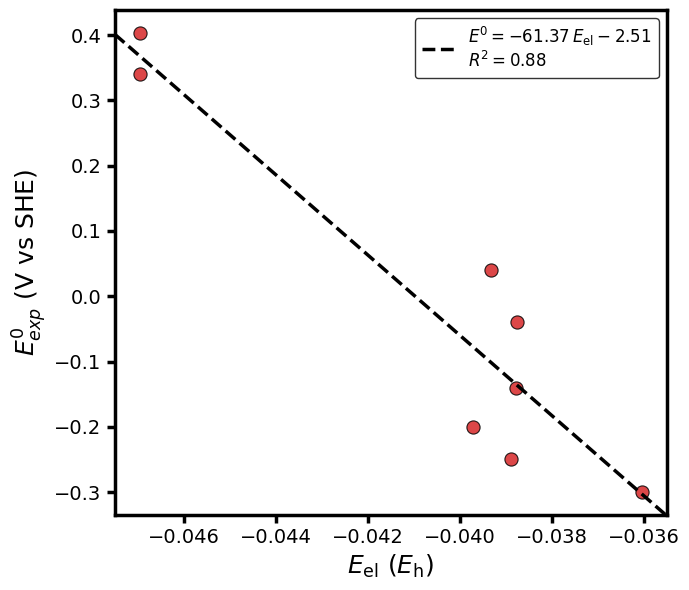

In [4]:
# -------------------------------------------------------------------
# Load RedDB and normalize experimental potentials to pH 0
# -------------------------------------------------------------------

reddb = pd.read_csv("reddb.csv")

reddb["reactionEnergy"] = pd.to_numeric(
    reddb["reactionEnergy"],
    errors="coerce",
)

NERNST_SLOPE = -0.050  # V per pH unit, obtained from the centred pH analysis

experimental = experimental_raw.copy()

# E(pH) = E(pH 0) + slope × pH
# Therefore: E(pH 0) = E(pH) - slope × pH
experimental["potential_pH0"] = (
    experimental["experimentalPotential"]
    - NERNST_SLOPE * experimental["pH"]
)

# -------------------------------------------------------------------
# Match RedDB oxidized reactants to experimental molecular records
# -------------------------------------------------------------------

matched = reddb.merge(
    experimental,
    left_on="inchikey_ox",
    right_on="inchiKey",
    how="inner",
)

matched = matched.dropna(
    subset=["reactionEnergy", "potential_pH0"]
).drop_duplicates(
    subset=["inchikey_ox", "reactionEnergy", "potential_pH0"]
).copy()

print(f"RedDB reactions: {len(reddb)}")
print(f"Matched RedDB–OFBO records: {len(matched)}")

display(
    matched[
        [
            "inchikey_ox",
            "smiles_ox",
            "reactionEnergy",
            "experimentalPotential",
            "pH",
            "potential_pH0",
            "source",
        ]
    ]
)

# -------------------------------------------------------------------
# Linear regression and visualization
# -------------------------------------------------------------------

x = matched["reactionEnergy"].to_numpy()
y = matched["potential_pH0"].to_numpy()

slope, intercept, r_value, p_value, std_error = stats.linregress(x, y)
r_squared = r_value ** 2

plt.figure(figsize=(7, 6))
ax = plt.gca()

# Matched RedDB–experimental data points.
ax.scatter(
    x,
    y,
    s=90,
    color="#d62728",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85,
)

# axline extends the fitted line across the complete plotting area.
fit_line = ax.axline(
    (np.mean(x), np.mean(y)),
    slope=slope,
    color="black",
    linestyle="--",
    linewidth=2.5,
)

ax.set_xlabel(
    r"$E_{\mathrm{el}}$ ($E_\mathrm{h}$)",
    fontsize=18,
)

ax.set_ylabel(
    r"$E^{0}_{exp}$ (V vs SHE)",
    fontsize=18,
)

ax.tick_params(axis="both", labelsize=14, width=2.5, length=6)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

ax.grid(False)

equation = (
    rf"$E^0 = {slope:.2f}\,E_{{\mathrm{{el}}}}"
    rf"{intercept:+.2f}$"
    "\n"
    rf"$R^2 = {r_squared:.2f}$"
)

ax.legend(
    [fit_line],
    [equation],
    loc="upper right",
    fontsize=12,
    frameon=True,
    edgecolor="black",
)

plt.tight_layout()

plt.savefig(
    "reddb_experimental_redox_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()